# Retail Demand Forecasting

## 10. Business Insights and Recommendations

This stage translates the forecasting results into practical business insights.

The analysis focuses on demand behaviour, forecast accuracy, promotional activity, seasonal patterns, and forecast error implications for inventory and operational planning.

The objective is to demonstrate how forecasting models can support real-world retail decision-making rather than evaluating model performance in isolation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

OUTPUT_PATH = "outputs/tables"

In [2]:
final_summary = pd.read_csv(
    f"{OUTPUT_PATH}/final_forecast_summary.csv"
)

final_model_comparison = pd.read_csv(
    f"{OUTPUT_PATH}/final_model_comparison.csv"
)

final_forecast = pd.read_csv(
    f"{OUTPUT_PATH}/final_forecast_with_errors.csv"
)

final_forecast["date"] = pd.to_datetime(
    final_forecast["date"]
)

final_summary

,Selected Model,MAE,RMSE,MAPE (%),Overforecast Days,Underforecast Days,Average Overforecast Error,Average Underforecast Error
0,Seasonal Naive,139.25,550.04,8.42,18,12,967.10,595.53


## 10.1 Overall Demand Profile

The overall demand profile is examined to understand the scale and variability of sales throughout the historical period.

Understanding the underlying demand level provides context for interpreting the forecasting results.

In [3]:
demand_statistics = pd.DataFrame({
    "Metric": [
        "Average Daily Sales",
        "Median Daily Sales",
        "Minimum Daily Sales",
        "Maximum Daily Sales",
        "Sales Standard Deviation"
    ],
    "Value": [
        final_forecast["actual_sales"].mean(),
        final_forecast["actual_sales"].median(),
        final_forecast["actual_sales"].min(),
        final_forecast["actual_sales"].max(),
        final_forecast["actual_sales"].std()
    ]
})

demand_statistics

,Metric,Value
0,Average Daily Sales,"10,016.10"
1,Median Daily Sales,"9,909.00"
2,Minimum Daily Sales,"7,302.00"
3,Maximum Daily Sales,"12,494.00"
4,Sales Standard Deviation,"1,365.90"


In [4]:
mean_sales = final_forecast["actual_sales"].mean()
std_sales = final_forecast["actual_sales"].std()

coefficient_variation = (
    std_sales / mean_sales
) * 100

print(
    f"Demand coefficient of variation: "
    f"{coefficient_variation:.2f}%"
)

Demand coefficient of variation: 13.64%


## 10.2 Monthly Demand Pattern

Monthly demand patterns are analyzed to identify recurring seasonal behaviour that may influence inventory and operational planning.

In [5]:
monthly_sales = (
    final_forecast
    .assign(
        month=final_forecast["date"].dt.month
    )
    .groupby("month")["actual_sales"]
    .mean()
    .reset_index()
)

monthly_sales

,month,actual_sales
0,7,"9,885.32"
1,8,"10,242.00"


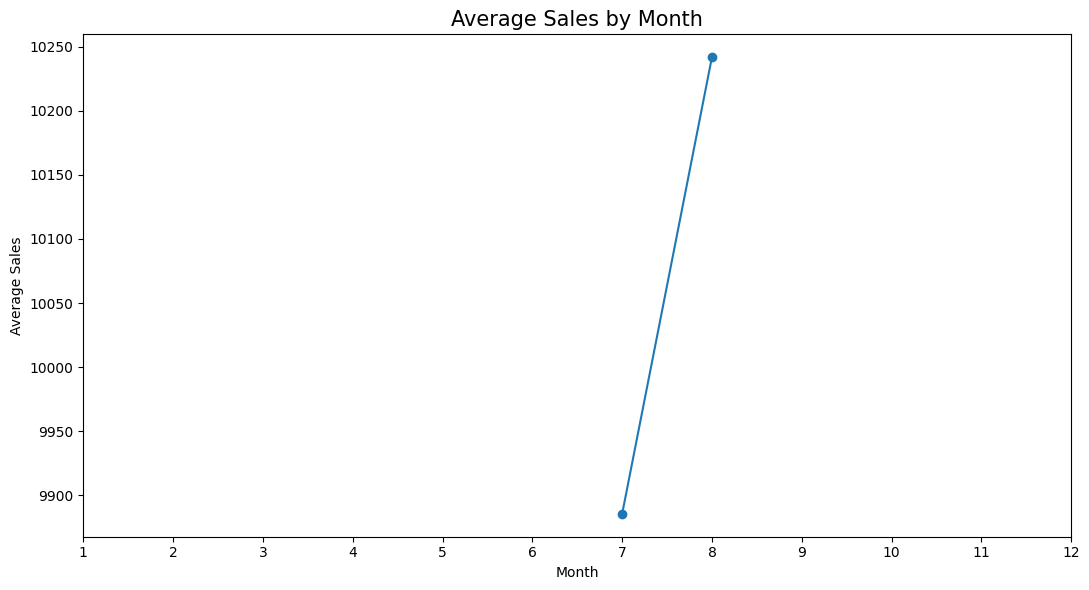

In [6]:
plt.figure(figsize=(11, 6))

plt.plot(
    monthly_sales["month"],
    monthly_sales["actual_sales"],
    marker="o"
)

plt.title(
    "Average Sales by Month",
    fontsize=15
)

plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [7]:
peak_month = monthly_sales.loc[
    monthly_sales["actual_sales"].idxmax(),
    "month"
]

low_month = monthly_sales.loc[
    monthly_sales["actual_sales"].idxmin(),
    "month"
]

print(f"Peak demand month: {peak_month}")
print(f"Lowest demand month: {low_month}")

Peak demand month: 8
Lowest demand month: 7


## 10.3 Day-of-Week Demand Patterns

Average sales are compared across days of the week to identify recurring weekly demand patterns.

In [8]:
weekday_sales = (
    final_forecast
    .assign(
        day_of_week=final_forecast["date"].dt.dayofweek
    )
    .groupby("day_of_week")["actual_sales"]
    .mean()
    .reset_index()
)

weekday_sales["day_name"] = (
    pd.to_datetime(
        weekday_sales["day_of_week"],
        unit="D",
        origin="2024-01-01"
    )
    .dt.day_name()
)

weekday_sales

,day_of_week,actual_sales,day_name
0,0,"10,794.00",Monday
1,1,"9,567.17",Tuesday
2,2,"10,277.67",Wednesday
3,3,"8,427.83",Thursday
4,4,"11,013.83",Friday


In [9]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

weekday_sales["day_name"] = (
    weekday_sales["day_of_week"]
    .map(day_names)
)

weekday_sales

,day_of_week,actual_sales,day_name
0,0,"10,794.00",Monday
1,1,"9,567.17",Tuesday
2,2,"10,277.67",Wednesday
3,3,"8,427.83",Thursday
4,4,"11,013.83",Friday


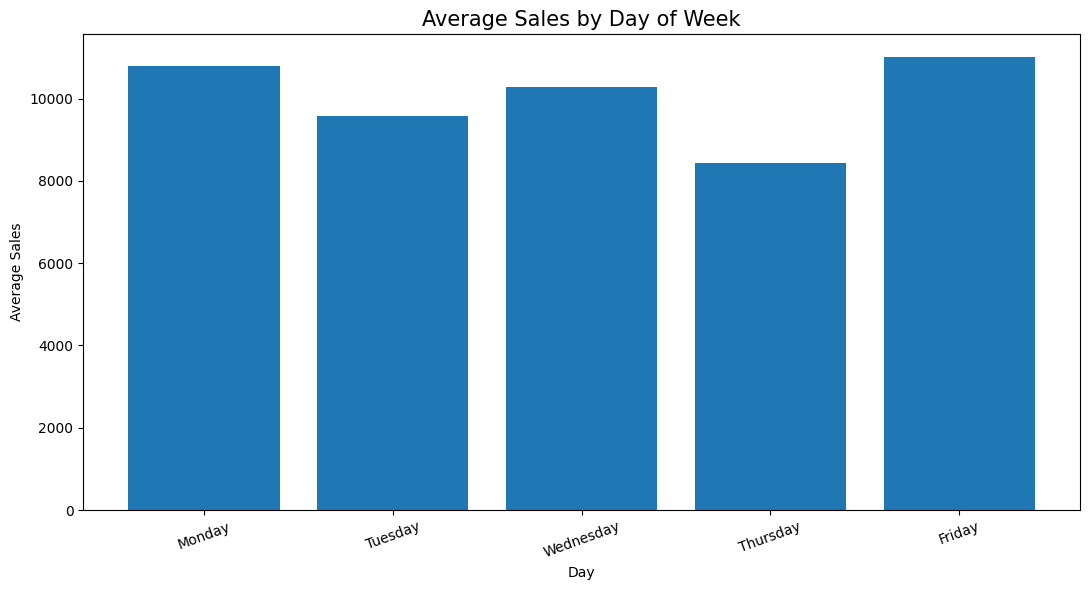

In [10]:
plt.figure(figsize=(11, 6))

plt.bar(
    weekday_sales["day_name"],
    weekday_sales["actual_sales"]
)

plt.title(
    "Average Sales by Day of Week",
    fontsize=15
)

plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 10.4 Promotional Demand Analysis

The relationship between promotional activity and sales is examined to determine whether periods with promotional activity are associated with higher demand.

This provides insight into how promotions may influence inventory requirements.

In [11]:
required_columns = [
    "date",
    "store_nbr",
    "family",
    "sales",
    "onpromotion"
]

selected_store = 45
selected_family = "GROCERY I"

In [12]:
promotion_parts = []

for chunk in pd.read_csv(
    f"{OUTPUT_PATH}/forecasting_features.csv",
    usecols=required_columns,
    chunksize=200_000
):
    
    selected = chunk[
        (chunk["store_nbr"] == selected_store) &
        (chunk["family"] == selected_family)
    ].copy()

    if not selected.empty:
        promotion_parts.append(selected)

promotion_data = pd.concat(
    promotion_parts,
    ignore_index=True
)

promotion_data["date"] = pd.to_datetime(
    promotion_data["date"]
)

promotion_data = (
    promotion_data
    .sort_values("date")
    .drop_duplicates("date")
    .reset_index(drop=True)
)

print(
    f"Promotion dataset shape: "
    f"{promotion_data.shape}"
)

Promotion dataset shape: (1656, 5)


In [13]:
promotion_summary = (
    promotion_data
    .assign(
        promotion_status=np.where(
            promotion_data["onpromotion"] > 0,
            "Promotion",
            "No Promotion"
        )
    )
    .groupby("promotion_status")["sales"]
    .agg(
        ["mean", "median", "count"]
    )
    .reset_index()
)

promotion_summary

,promotion_status,mean,median,count
0,No Promotion,"8,040.90","7,172.00",519
1,Promotion,"10,543.73","9,622.00",1137


In [14]:
promotion_sales = promotion_summary.loc[
    promotion_summary["promotion_status"] == "Promotion",
    "mean"
].iloc[0]

nonpromotion_sales = promotion_summary.loc[
    promotion_summary["promotion_status"] == "No Promotion",
    "mean"
].iloc[0]

promotion_difference = (
    (promotion_sales - nonpromotion_sales)
    / nonpromotion_sales
) * 100

print(
    f"Average sales difference during promotions: "
    f"{promotion_difference:.2f}%"
)

Average sales difference during promotions: 31.13%


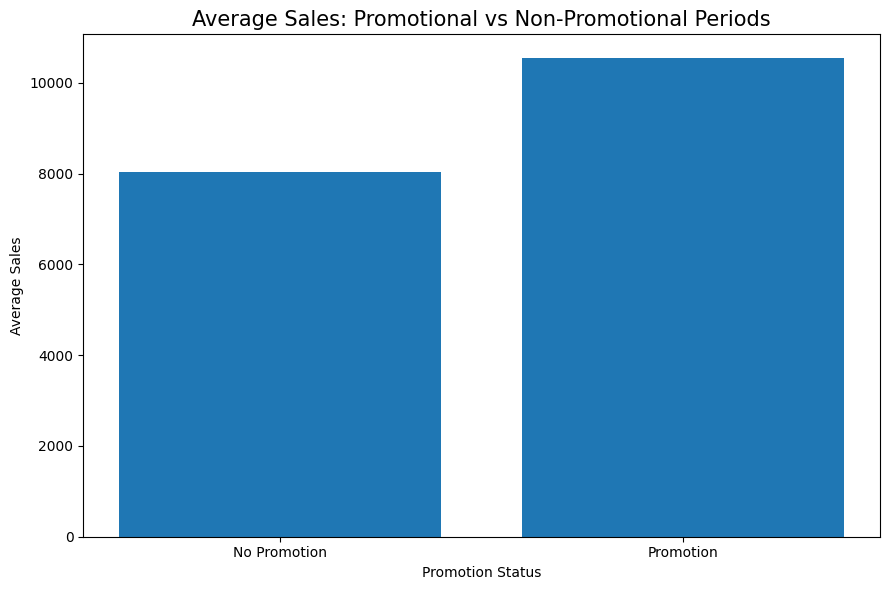

In [15]:
plt.figure(figsize=(9, 6))

plt.bar(
    promotion_summary["promotion_status"],
    promotion_summary["mean"]
)

plt.title(
    "Average Sales: Promotional vs Non-Promotional Periods",
    fontsize=15
)

plt.xlabel("Promotion Status")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

## 10.5 Forecast Accuracy Over Time

Forecast errors are examined throughout the test period to identify whether model performance deteriorates during periods of unusually high or low demand.

In [16]:
final_forecast["abs_percentage_error"] = (
    final_forecast["absolute_error"]
    / final_forecast["actual_sales"].replace(0, np.nan)
) * 100

final_forecast[
    [
        "date",
        "actual_sales",
        "forecast_sales",
        "absolute_error",
        "abs_percentage_error"
    ]
].sort_values(
    "abs_percentage_error",
    ascending=False
).head(10)

,date,actual_sales,forecast_sales,absolute_error,abs_percentage_error
21,2017-08-03,"9,583.00","12,824.64","3,241.64",33.83
4,2017-07-11,"8,228.00","9,789.75","1,561.75",18.98
1,2017-07-06,"8,613.00","9,904.88","1,291.88",15.00
5,2017-07-12,"8,692.00","9,875.93","1,183.93",13.62
18,2017-07-31,"11,544.00","13,080.69","1,536.69",13.31
8,2017-07-17,"11,377.00","9,875.66","1,501.34",13.20
28,2017-08-14,"9,665.00","10,848.29","1,183.29",12.24
6,2017-07-13,"7,302.00","8,138.07",836.07,11.45
24,2017-08-08,"8,693.00","9,572.91",879.91,10.12
23,2017-08-07,"10,574.00","11,577.34","1,003.34",9.49


In [17]:
demand_median = (
    final_forecast["actual_sales"]
    .median()
)

final_forecast["demand_level"] = np.where(
    final_forecast["actual_sales"] >= demand_median,
    "High Demand",
    "Low Demand"
)

demand_accuracy = (
    final_forecast
    .groupby("demand_level")
    .agg(
        MAE=("absolute_error", "mean"),
        Average_Sales=("actual_sales", "mean")
    )
    .reset_index()
)

demand_accuracy

,demand_level,MAE,Average_Sales
0,High Demand,667.47,"11,177.73"
1,Low Demand,969.48,"8,854.47"


## 10.6 Business Interpretation

### Inventory Planning

Accurate demand forecasts can support inventory replenishment by providing estimates of expected future sales. Higher forecast uncertainty should be considered when determining safety-stock levels.

### Promotional Planning

Periods associated with promotional activity should be monitored carefully because changes in demand can increase the risk of understocking.

### Staffing and Operations

Recurring weekly and monthly demand patterns can support staffing and operational planning by identifying periods of consistently higher demand.

### Forecast Risk

Underforecasting may result in stockouts and missed sales, while overforecasting may increase excess inventory and holding costs. Therefore, forecast accuracy should be evaluated together with the operational cost of forecast errors.

### Model Deployment

In a production environment, the forecasting pipeline could be executed regularly to generate updated forecasts as new sales, promotion, and external-factor data become available.

In [18]:
business_metrics = pd.DataFrame([
    {
        "Metric": "Demand Variability",
        "Value": coefficient_variation,
        "Unit": "%"
    },
    {
        "Metric": "Promotion Sales Difference",
        "Value": promotion_difference,
        "Unit": "%"
    },
    {
        "Metric": "Peak Demand Month",
        "Value": peak_month,
        "Unit": "Month"
    },
    {
        "Metric": "Lowest Demand Month",
        "Value": low_month,
        "Unit": "Month"
    },
    {
        "Metric": "Overforecast Days",
        "Value": final_forecast["forecast_sales"].gt(
            final_forecast["actual_sales"]
        ).sum(),
        "Unit": "Days"
    },
    {
        "Metric": "Underforecast Days",
        "Value": final_forecast["forecast_sales"].lt(
            final_forecast["actual_sales"]
        ).sum(),
        "Unit": "Days"
    }
])

business_metrics

,Metric,Value,Unit
0,Demand Variability,13.64,%
1,Promotion Sales Difference,31.13,%
2,Peak Demand Month,8.00,Month
3,Lowest Demand Month,7.00,Month
4,Overforecast Days,18.00,Days
5,Underforecast Days,12.00,Days


In [19]:
monthly_sales.to_csv(
    f"{OUTPUT_PATH}/business_monthly_sales.csv",
    index=False
)

weekday_sales.to_csv(
    f"{OUTPUT_PATH}/business_weekday_sales.csv",
    index=False
)

promotion_summary.to_csv(
    f"{OUTPUT_PATH}/business_promotion_summary.csv",
    index=False
)

demand_accuracy.to_csv(
    f"{OUTPUT_PATH}/business_demand_accuracy.csv",
    index=False
)

business_metrics.to_csv(
    f"{OUTPUT_PATH}/business_metrics.csv",
    index=False
)

print(
    "Business analysis outputs saved successfully."
)

Business analysis outputs saved successfully.


# Phase 10 Summary

The forecasting results were translated into practical business insights covering demand variability, seasonality, promotional activity, forecast error behaviour, and operational risk.

The analysis demonstrates how demand forecasting can support inventory planning, promotional preparation, staffing decisions, and operational resource allocation.

The results also highlight the importance of considering both forecast accuracy and the asymmetric business consequences of overforecasting and underforecasting.

These findings provide the foundation for the final project conclusions and portfolio documentation.